# Visualization Lead
Analyzing customer demographics, purchase behavior, and churn patterns from the cleaned dataset.
Use this notebook to explore revenue drivers, product returns, and customer retention metrics visually.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better visuals
sns.set_theme(style="whitegrid")

## 1. Load Cleaned Data
Loading the cleaned data which has been processed by the `01_cleaning.ipynb` notebook.

In [9]:
# The cleaned data is located within the same notebooks directory under data/cleaned/
df = pd.read_csv('data/cleaned/ecommerce_customer_data_cleaned.csv')
print("Data loaded successfully. Shape:", df.shape)
df.head()

Data loaded successfully. Shape: (250000, 14)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn,Calculated_Total,Amount_Difference
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,0.0,Christine Hernandez,37,Female,0,36,704
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,0.0,Christine Hernandez,37,Female,0,1872,867
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,0.0,Christine Hernandez,37,Female,0,576,2620
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,0.0,Christine Hernandez,37,Female,0,196,3313
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,0.0,James Grant,49,Male,1,449,3003


## 2. Customer Demographics
Visualizing Age and Gender distributions to understand the active customer base.

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\3486664334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


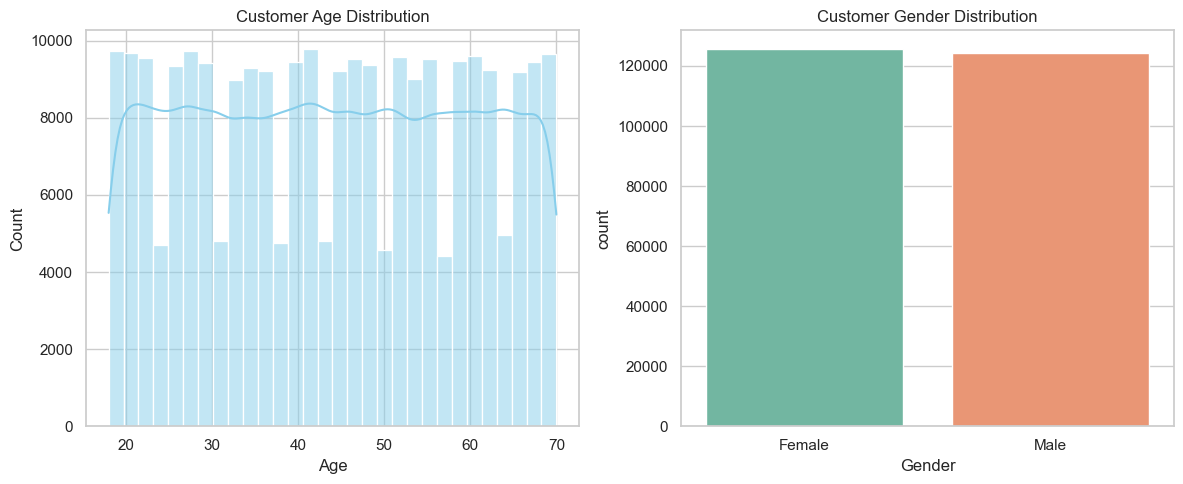

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue')
plt.title('Customer Age Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Customer Gender Distribution')

plt.tight_layout()
plt.show()

## 3. Revenue Drivers / Purchase Behavior
Identifying high-value product categories by visualizing total revenue and purchase amounts.

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\45068039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')


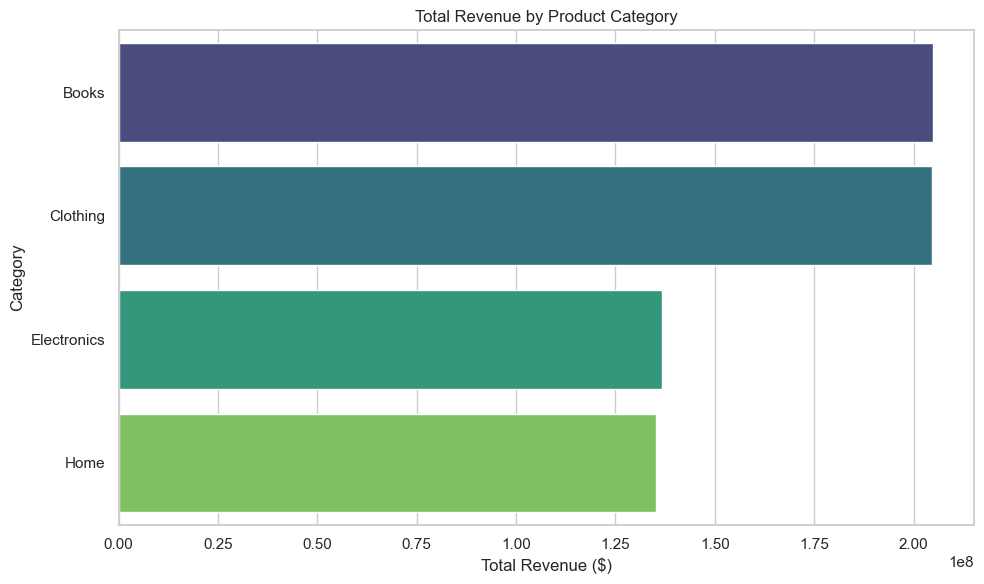

In [11]:
plt.figure(figsize=(10, 6))
category_revenue = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\741421006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product Category', y='Total Purchase Amount', palette='pastel')


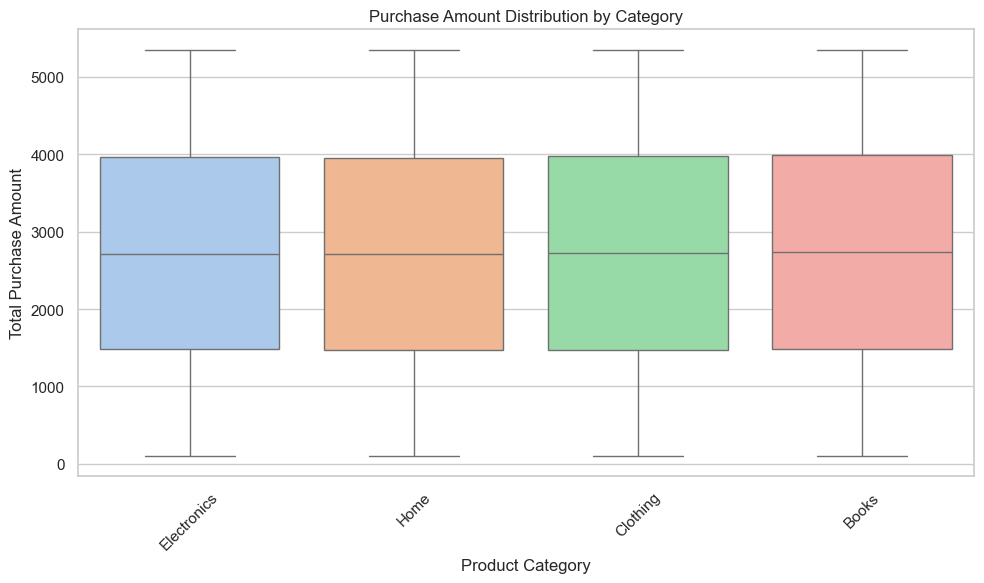

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product Category', y='Total Purchase Amount', palette='pastel')
plt.title('Purchase Amount Distribution by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Product Returns and Customer Churn
Analyzing retention by viewing overall churn and specific return rates across product categories.

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\2959818689.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='coolwarm')
C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\2959818689.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=return_rate.values, y=return_rate.index, palette='magma')


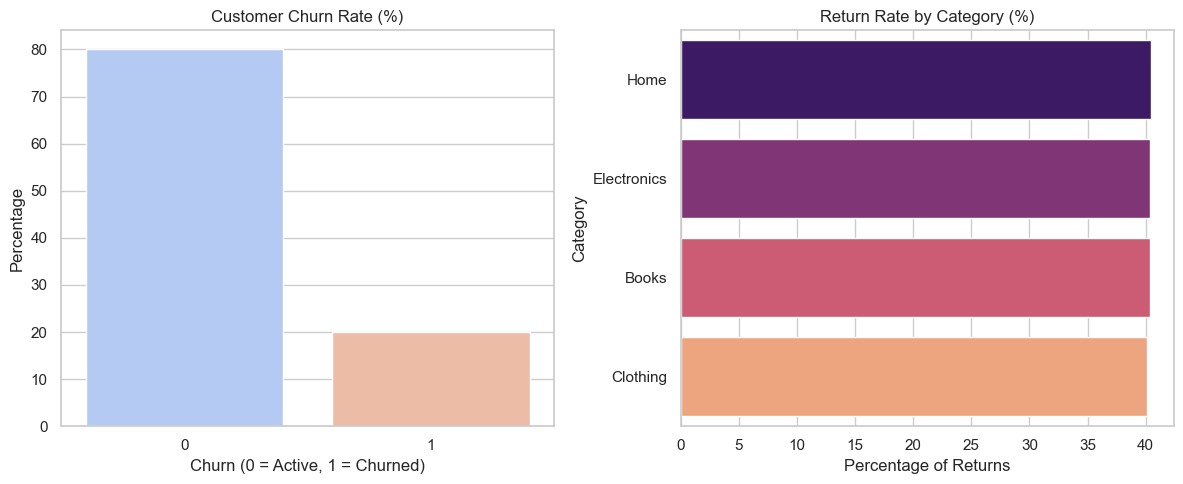

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
churn_rate = df['Churn'].value_counts(normalize=True) * 100
sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='coolwarm')
plt.title('Customer Churn Rate (%)')
plt.xlabel('Churn (0 = Active, 1 = Churned)')
plt.ylabel('Percentage')

plt.subplot(1, 2, 2)
return_rate = df.groupby('Product Category')['Returns'].mean().sort_values(ascending=False) * 100
sns.barplot(x=return_rate.values, y=return_rate.index, palette='magma')
plt.title('Return Rate by Category (%)')
plt.xlabel('Percentage of Returns')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

## 5. Demographics vs. Revenue
Visualizing how customer age and gender impact purchasing power.

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\2861462184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Gender', y='Total Purchase Amount', palette='Set2', errorbar=None)
C:\Users\zuko\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


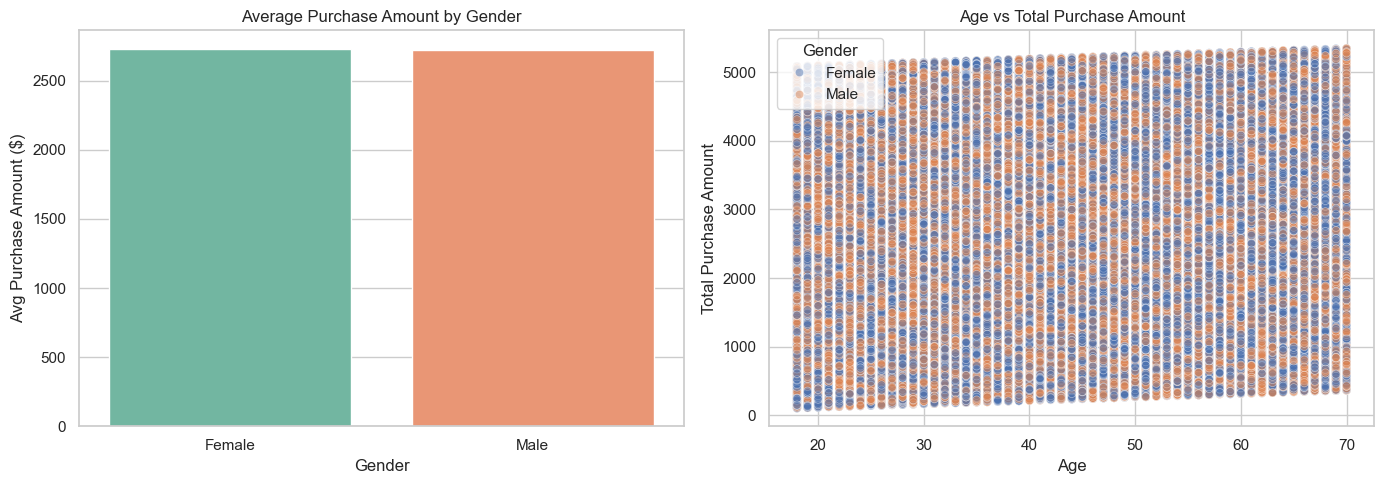

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Gender', y='Total Purchase Amount', palette='Set2', errorbar=None)
plt.title('Average Purchase Amount by Gender')
plt.ylabel('Avg Purchase Amount ($)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Age', y='Total Purchase Amount', hue='Gender', alpha=0.5)
plt.title('Age vs Total Purchase Amount')

plt.tight_layout()
plt.show()

## 6. Deeper Dive into Churn & Retention
Analyzing churn in relation to customer demographics and return behavior.

C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\1075964766.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Age', palette='coolwarm')
C:\Users\zuko\AppData\Local\Temp\ipykernel_17088\1075964766.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=return_churn.index, y=return_churn.values, palette='magma')


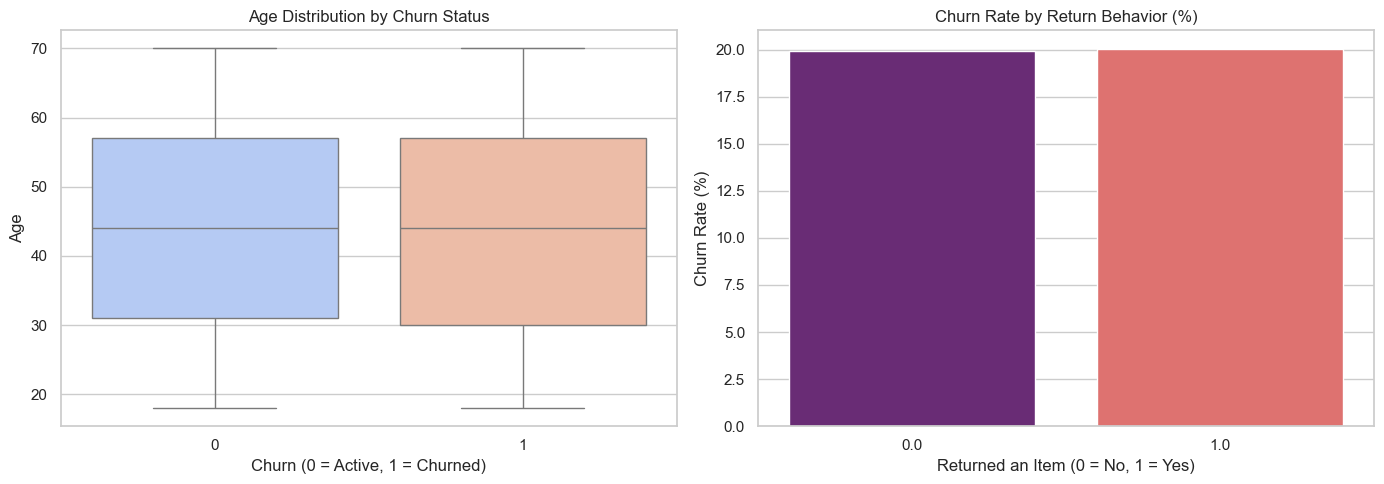

In [15]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Churn', y='Age', palette='coolwarm')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Churn (0 = Active, 1 = Churned)')

plt.subplot(1, 2, 2)
return_churn = df.groupby('Returns')['Churn'].mean() * 100
sns.barplot(x=return_churn.index, y=return_churn.values, palette='magma')
plt.title('Churn Rate by Return Behavior (%)')
plt.xlabel('Returned an Item (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()